# VAR Hands-on Übung – Musterlösung mit Erklärungen

Dieses Notebook enthält die **vollständige Lösung** der VAR-Übung samt
Begründungen. Es eignet sich zum Nacharbeiten und als Nachschlagewerk.

Roter Faden: Wir bauen ein Vector-Autoregression-Modell mit reinem `numpy`/`pandas`
nach und durchlaufen den typischen Workflow – **Lag-Matrix → OLS → Lag-Auswahl →
Forecast → Bewertung → Stabilität → Impulsantwort**.


## 0 · Setup und Daten

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

pd.set_option("display.float_format", lambda v: f"{v:0.3f}")
np.set_printoptions(suppress=True, precision=3)

# Datenpfad robust finden (egal ob das Notebook im Projektordner oder in einem
# Unterordner liegt).
CANDIDATES = [Path("data"), Path("../data"), Path("../../data")]
DATA_DIR = next((p for p in CANDIDATES if (p / "var_fred_macro.csv").exists()), None)
assert DATA_DIR is not None, (
    "var_fred_macro.csv wurde nicht gefunden. "
    "Lege das Notebook in der Naehe des data-Ordners ab."
)

COLS = [
    "inflation_yoy",
    "unemployment_rate",
    "fed_funds_rate",
    "industrial_production_growth_yoy",
]
NAMES = {
    "inflation_yoy": "Inflation",
    "unemployment_rate": "Arbeitslosigkeit",
    "fed_funds_rate": "Fed Funds Rate",
    "industrial_production_growth_yoy": "Industrieproduktion",
}

data = (
    pd.read_csv(DATA_DIR / "var_fred_macro.csv", parse_dates=["date"])
    .set_index("date")[COLS]
    .dropna()
)
print("Form (Zeilen, Spalten):", data.shape)
print("Zeitraum:", data.index.min().date(), "bis", data.index.max().date())
data.head()

Form (Zeilen, Spalten): (408, 4)
Zeitraum: 1991-01-01 bis 2024-12-01


,inflation_yoy,unemployment_rate,fed_funds_rate,industrial_production_growth_yoy
date,,,,
1991-01-01,5.493,6.400,6.910,-0.966
1991-02-01,5.176,6.600,6.250,-2.612
1991-03-01,4.709,6.800,6.120,-3.686
1991-04-01,4.698,6.700,5.910,-3.160
1991-05-01,4.912,6.900,5.780,-2.527


In [2]:
def check(name, condition):
    print(("OK   " if condition else "FALSCH ") + name)
    assert condition, f"Self-Check fehlgeschlagen: {name}"


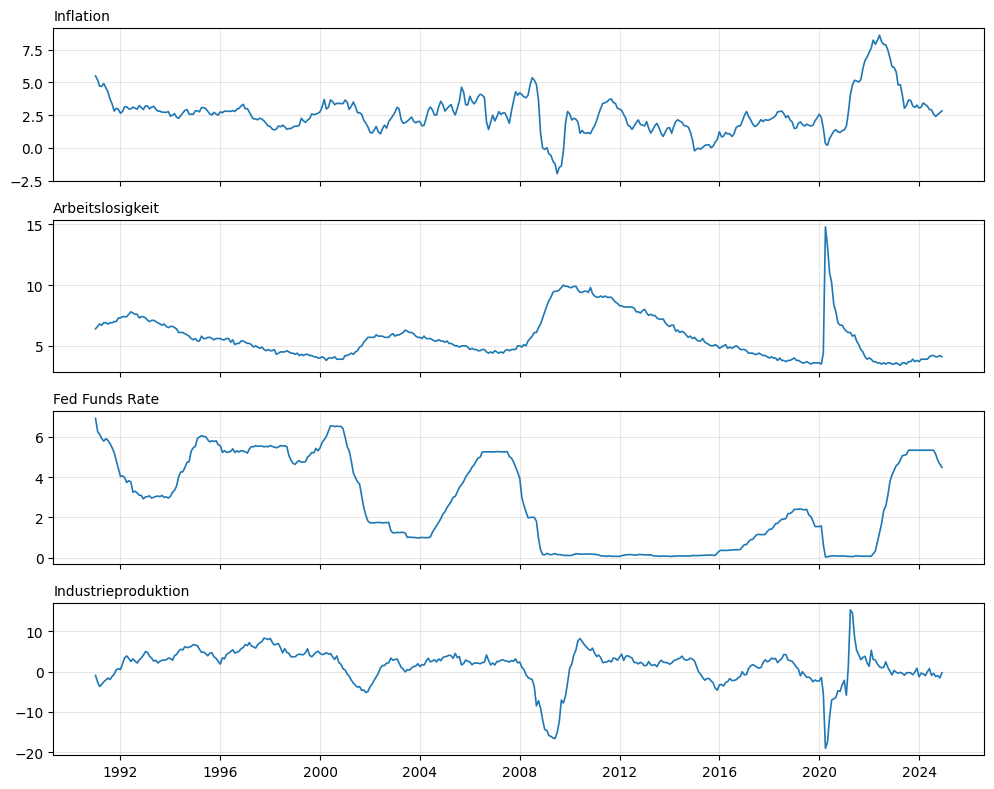

In [3]:
fig, axes = plt.subplots(len(COLS), 1, figsize=(10, 8), sharex=True)
for ax, c in zip(axes, COLS):
    ax.plot(data.index, data[c], lw=1.2)
    ax.set_title(NAMES[c], loc="left", fontsize=10)
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**Was sieht man?** Vier Reihen auf sehr unterschiedlichen Skalen mit
sichtbarer Persistenz (Werte hängen stark vom Vormonat ab). Genau diese
gegenseitige Dynamik will ein VAR ausnutzen. Für die Modellierung
z-standardisieren wir, damit alle Reihen vergleichbar sind:


In [4]:
# Fuer das Verstaendnis des Modells arbeiten wir zunaechst auf z-standardisierten
# Reihen (Mittelwert 0, Standardabweichung 1). Das macht Koeffizienten und
# Impulsantworten ueber unterschiedliche Skalen hinweg vergleichbar.
# Hinweis: Fuer die spaetere FAIRE Forecast-Bewertung standardisieren wir noch
# einmal getrennt - nur mit den Trainingsdaten (kein Data-Leakage).
Z = (data - data.mean()) / data.std(ddof=0)
Z.describe().T[["mean", "std", "min", "max"]]

,mean,std,min,max
inflation_yoy,0.000,1.001,-3.009,3.979
unemployment_rate,0.000,1.001,-1.308,5.128
fed_funds_rate,0.000,1.001,-1.190,1.907
industrial_production_growth_yoy,0.000,1.001,-4.711,3.215


## 1 · Lag-Matrix – das VAR als Regressionsproblem

Ein VAR(p) ist im Kern eine **lineare Regression**. Für jeden Zeitpunkt $t$
bilden wir eine Zeile in $X$ aus einem Intercept und den letzten $p$ Beobachtungs-
vektoren; die Zielzeile in $Y$ ist $y_t$:

$$ \underbrace{y_t}_{Y} = \underbrace{[\,1 \;\; y_{t-1} \;\; \dots \;\; y_{t-p}\,]}_{X} \cdot \beta + u_t $$

Bei $k$ Variablen und Lag $p$ hat $X$ also $1 + k\cdot p$ Spalten. Durch das
Verschieben „verlieren“ wir die ersten $p$ Zeilen.


In [5]:
def make_lag_matrix(frame, p):
    # Baut die Designmatrix X und die Zielmatrix Y fuer ein VAR(p).
    # X = [const | y_{t-1} | y_{t-2} | ... | y_{t-p}],  Y = y_t
    arr = np.asarray(frame, dtype=float)
    n, k = arr.shape

    X_parts = [np.ones((n - p, 1))]      # 1. Spalte: Intercept (Einsen)
    names = ["const"]

    for lag in range(1, p + 1):
        # Lag `lag` heisst: Zeile t bekommt den Wert von t-lag.
        # Fuer die Zielzeilen t = p .. n-1 sind das die Zeilen p-lag .. n-1-lag.
        X_parts.append(arr[p - lag : n - lag])
        names += [f"{c}_lag{lag}" for c in frame.columns]

    X = np.hstack(X_parts)
    Y = arr[p:]                          # die zu erklaerenden Werte y_t
    return X, Y, names

In [6]:
X, Y, names = make_lag_matrix(Z, 2)
k = Z.shape[1]
check("X hat Form (n-p, 1 + k*p)", X.shape == (len(Z) - 2, 1 + k * 2))
check("Y hat Form (n-p, k)", Y.shape == (len(Z) - 2, k))
check("erste Spalte ist Intercept (alles 1)", np.allclose(X[:, 0], 1.0))
check("Lag-1-Block ist korrekt verschoben", np.allclose(X[:, 1:1 + k], Z.values[1:-1]))
check("Y entspricht arr[p:]", np.allclose(Y, Z.values[2:]))
print("Spaltennamen:", names)

OK   X hat Form (n-p, 1 + k*p)
OK   Y hat Form (n-p, k)
OK   erste Spalte ist Intercept (alles 1)
OK   Lag-1-Block ist korrekt verschoben
OK   Y entspricht arr[p:]
Spaltennamen: ['const', 'inflation_yoy_lag1', 'unemployment_rate_lag1', 'fed_funds_rate_lag1', 'industrial_production_growth_yoy_lag1', 'inflation_yoy_lag2', 'unemployment_rate_lag2', 'fed_funds_rate_lag2', 'industrial_production_growth_yoy_lag2']


## 2 · Schätzung per OLS

Alle $k$ Gleichungen eines Reduced-Form-VAR teilen sich **dieselben** Regressoren
$X$. Deshalb genügt ein einziges `lstsq`, das die Koeffizientenmatrix für alle
Zielvariablen gleichzeitig liefert. Die **Residuen** $u_t = Y - X\beta$ sind die
Modellfehler; ihre Kovarianzmatrix $\Sigma_u$ brauchen wir gleich für AIC/BIC.


In [7]:
def fit_var(frame, p):
    X, Y, names = make_lag_matrix(frame, p)

    # OLS, gleichungsweise und gemeinsam: jede Spalte von Y ist eine Gleichung,
    # alle nutzen dieselben Regressoren X -> ein einziges lstsq genuegt.
    coef = np.linalg.lstsq(X, Y, rcond=None)[0]

    resid = Y - X @ coef                       # Modellfehler / Innovationen
    sigma_u = (resid.T @ resid) / len(resid)   # Residual-Kovarianzmatrix
    return {
        "p": p,
        "columns": list(frame.columns),
        "coef": coef,
        "resid": resid,
        "sigma_u": sigma_u,
        "x_names": names,
    }

In [8]:
m = fit_var(Z, 2)
X, Y, _ = make_lag_matrix(Z, 2)
check("coef hat Form (1 + k*p, k)", m["coef"].shape == (1 + Z.shape[1] * 2, Z.shape[1]))
check("Residuen stehen senkrecht auf X (OLS-Eigenschaft)", np.allclose(X.T @ m["resid"], 0, atol=1e-6))
check("sigma_u ist k x k", m["sigma_u"].shape == (Z.shape[1], Z.shape[1]))

# Koeffizienten von Lag 1 als kleine Heatmap-Tabelle (Zeile = Ziel heute,
# Spalte = Quelle in t-1).
k = Z.shape[1]
block = pd.DataFrame(m["coef"][1:1 + k, :].T, index=COLS, columns=COLS)
block.rename(index=NAMES, columns=NAMES).round(3)

OK   coef hat Form (1 + k*p, k)
OK   Residuen stehen senkrecht auf X (OLS-Eigenschaft)
OK   sigma_u ist k x k


,Inflation,Arbeitslosigkeit,Fed Funds Rate,Industrieproduktion
Inflation,1.356,0.035,0.271,0.033
Arbeitslosigkeit,-0.111,0.858,-1.199,-0.078
Fed Funds Rate,-0.008,0.025,1.588,0.019
Industrieproduktion,0.223,0.099,0.978,1.107


**Lesart der Koeffizienten (Lag 1):** Eine Zeile zeigt, wie die heutige
Variable von den Werten *aller* Variablen im Vormonat abhängt. Positive Werte =
gleichläufig, negative = gegenläufig. Einzelne Koeffizienten sind aber schwer zu
interpretieren, weil sich Effekte über mehrere Lags verteilen – dafür gibt es
später die Impulsantworten.


## 3 · Lag-Ordnung mit AIC/BIC

$$ \text{AIC} = \ln|\Sigma_u| + \frac{2\,m}{n}, \qquad
   \text{BIC} = \ln|\Sigma_u| + \frac{\ln(n)\,m}{n} $$

mit $m = K(Kp+1)$ Parametern und $n$ effektiven Beobachtungen. Beide belohnen ein
kleines $\ln|\Sigma_u|$ (guter Fit) und bestrafen Komplexität. **BIC** bestraft
mit $\ln(n)$ deutlich stärker als **AIC** mit $2$ und wählt daher meist sparsamere
Modelle. Wir nutzen `slogdet` für eine numerisch stabile Log-Determinante.


In [9]:
def information_criteria(frame, max_lag):
    k = frame.shape[1]
    rows = []
    for p in range(1, max_lag + 1):
        m = fit_var(frame, p)
        n = len(m["resid"])
        _, logdet = np.linalg.slogdet(m["sigma_u"])   # log|Sigma_u|
        params = k * (k * p + 1)                       # K*(K*p + 1) Parameter

        # AIC bestraft Parameter mild, BIC staerker (log(n) statt 2).
        aic = logdet + 2 * params / n
        bic = logdet + np.log(n) * params / n
        rows.append({"p": p, "aic": aic, "bic": bic})
    return pd.DataFrame(rows)

In [10]:
crit = information_criteria(Z, 8)
check("Spalten p, aic, bic vorhanden", {"p", "aic", "bic"}.issubset(crit.columns))
check("alle Kriterien endlich", np.isfinite(crit[["aic", "bic"]].values).all())

p_aic = int(crit.loc[crit["aic"].idxmin(), "p"])
p_bic = int(crit.loc[crit["bic"].idxmin(), "p"])
print(f"AIC waehlt p = {p_aic},  BIC waehlt p = {p_bic}")
crit.set_index("p").round(4)

OK   Spalten p, aic, bic vorhanden
OK   alle Kriterien endlich
AIC waehlt p = 4,  BIC waehlt p = 2


,aic,bic
p,,
1,-12.683,-12.486
2,-13.383,-13.028
3,-13.519,-13.005
4,-13.521,-12.848
5,-13.492,-12.659
6,-13.470,-12.476
7,-13.464,-12.308
8,-13.427,-12.109


**Beobachtung:** Typischerweise wählt AIC hier mehr Lags als BIC. Für
einen **Prognosefokus** ist das sparsamere BIC-Modell oft robuster (weniger
Overfitting), während AIC mehr Dynamik zulässt. Kein Kriterium ist immer
„richtig“ – die Wahl sollte zum Ziel passen.


## 4 · Mehrschritt-Forecast

Ein **dynamischer** (echter) Forecast nutzt nur die Trainingshistorie: Die
Prognose für Schritt 1 wird zur „Beobachtung“ für Schritt 2 und so weiter. Damit
akkumuliert sich Unsicherheit mit dem Horizont – realistisch für echte Zukunft.


In [11]:
def forecast_var(model, history, steps):
    # Echter Mehrschritt-Forecast: vorhergesagte Werte werden Schritt fuer
    # Schritt wieder als "Vergangenheit" eingespeist.
    p = int(model["p"])
    coef = model["coef"]
    hist = [row.copy() for row in np.asarray(history, dtype=float)[-p:]]
    preds = []

    for _ in range(steps):
        x = [1.0]                              # Intercept
        for lag in range(1, p + 1):
            x.extend(hist[-lag])               # zuletzt bekannte Werte anhaengen

        y = np.asarray(x) @ coef               # ein Schritt vorhersagen
        preds.append(y)
        hist.append(y)                         # Prognose wird neue "Historie"

    return np.asarray(preds)

In [12]:
m = fit_var(Z, 2)
f = forecast_var(m, Z, 5)
check("Forecast hat Form (steps, k)", f.shape == (5, Z.shape[1]))

# Der erste Schritt muss exakt x_last @ coef sein.
x_last = np.concatenate([[1.0], Z.values[-1], Z.values[-2]])
check("1-Schritt-Forecast ist konsistent", np.allclose(f[0], x_last @ m["coef"]))
print("Erste 3 prognostizierte (z-)Werte:")
pd.DataFrame(f, columns=COLS).head(3).rename(columns=NAMES).round(3)

OK   Forecast hat Form (steps, k)
OK   1-Schritt-Forecast ist konsistent
Erste 3 prognostizierte (z-)Werte:


,Inflation,Arbeitslosigkeit,Fed Funds Rate,Industrieproduktion
0,0.172,-0.827,0.758,-0.354
1,0.143,-0.747,0.721,-0.377
2,0.106,-0.681,0.692,-0.398


## 5 · Bewertung gegen eine naive Benchmark

Drei Dinge sind hier methodisch wichtig:

- **Zeitlicher Split** statt zufälligem Split – sonst lernt das Modell aus der
  Zukunft.
- **Standardisierung nur mit Trainings-Statistik** ($\mu,\sigma$ aus `train`) –
  sonst sickert Test-Information ins Training (*Data-Leakage*).
- **Naive Benchmark** (letzter Wert fortgeschrieben): Ein VAR ist nur dann
  überzeugend, wenn es diese einfache Messlatte schlägt.


In [13]:
# Train/Test-Split nach Zeit: die letzten H Monate sind Test.
H = 24
train = data.iloc[:-H]
test = data.iloc[-H:]

# Standardisieren NUR mit Trainings-Statistik -> kein Data-Leakage.
mu = train.mean()
sigma = train.std(ddof=0)
train_z = (train - mu) / sigma

# Lag per BIC auf den Trainingsdaten waehlen.
crit_train = information_criteria(train_z, 12)
p = int(crit_train.loc[crit_train["bic"].idxmin(), "p"])
print("Gewaehlter Lag p (BIC):", p)

# Modell schaetzen und H Schritte prognostizieren, danach zurueckskalieren.
model = fit_var(train_z, p)
fc_z = forecast_var(model, train_z, H)
fc = pd.DataFrame(fc_z * sigma.values + mu.values, index=test.index, columns=COLS)

# Naive Benchmark: letzter bekannter Wert wird einfach fortgeschrieben.
naive = pd.DataFrame(
    np.repeat(train.iloc[[-1]].values, H, axis=0), index=test.index, columns=COLS
)
fc.head()

Gewaehlter Lag p (BIC): 2


,inflation_yoy,unemployment_rate,fed_funds_rate,industrial_production_growth_yoy
date,,,,
2023-01-01,5.764,3.429,4.302,-1.141
2023-02-01,5.419,3.419,4.426,-1.334
2023-03-01,5.120,3.459,4.500,-1.510
2023-04-01,4.848,3.533,4.541,-1.686
2023-05-01,4.595,3.626,4.560,-1.851


In [14]:
rmse_var = np.sqrt(((fc - test) ** 2).mean())
rmse_naive = np.sqrt(((naive - test) ** 2).mean())

vergleich = pd.DataFrame({"VAR": rmse_var, "Naiv": rmse_naive})
vergleich["Gewinner"] = np.where(vergleich["VAR"] < vergleich["Naiv"], "VAR", "Naiv")
vergleich.rename(index=NAMES).round(3)

,VAR,Naiv,Gewinner
Inflation,0.441,2.886,VAR
Arbeitslosigkeit,0.616,0.408,Naiv
Fed Funds Rate,0.880,1.035,VAR
Industrieproduktion,1.416,0.685,Naiv


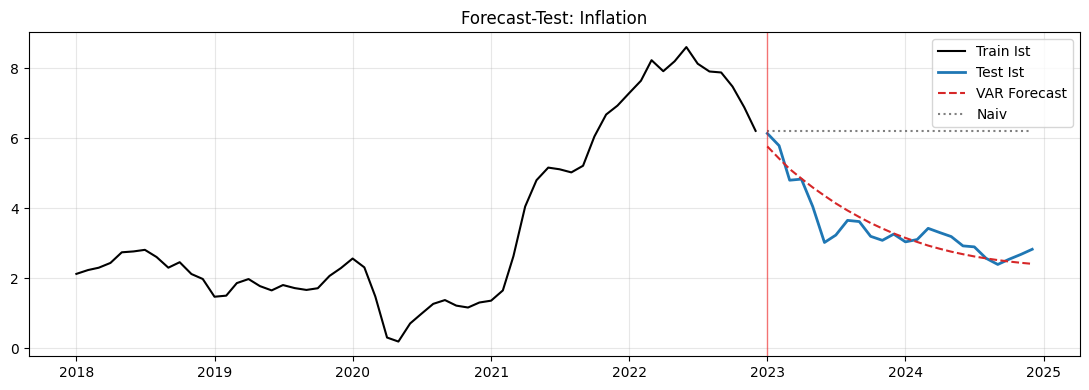

In [15]:
ziel = "inflation_yoy"   # gern aendern: eine der vier Variablen
plt.figure(figsize=(11, 4))
plt.plot(train.index[-60:], train[ziel].iloc[-60:], label="Train Ist", color="black")
plt.plot(test.index, test[ziel], label="Test Ist", color="tab:blue", lw=2)
plt.plot(fc.index, fc[ziel], "--", label="VAR Forecast", color="tab:red")
plt.plot(naive.index, naive[ziel], ":", label="Naiv", color="gray")
plt.axvline(test.index[0], color="red", lw=1, alpha=0.5)
plt.title(f"Forecast-Test: {NAMES[ziel]}")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**Interpretation:** Auf kurzen Horizonten und für persistente Reihen ist
die naive Prognose erstaunlich stark. Das VAR punktet vor allem dort, wo eine
Variable verzögert auf die anderen reagiert (gemeinsame Dynamik). Ergebnisse
hängen vom Horizont `H`, vom Lag `p` und von der Transformation ab – ruhig
variieren und vergleichen.


## 6 · Stabilität (Companion-Matrix)

Ein VAR(p) lässt sich als großes VAR(1) schreiben (Companion-Form). Liegen alle
Eigenwerte betragsmäßig **unter 1**, ist das System stabil: Schocks klingen ab,
Forecasts und Impulsantworten laufen nicht weg.


In [16]:
def companion_roots(model):
    # Stabilitaet: ein VAR ist stabil, wenn alle Eigenwerte der Companion-Matrix
    # betragsmaessig < 1 sind (Schocks klingen ab, Prognosen explodieren nicht).
    k = len(model["columns"])
    p = int(model["p"])
    coef = model["coef"]

    blocks = [coef[1 + lag * k : 1 + (lag + 1) * k, :].T for lag in range(p)]
    top = np.hstack(blocks)

    if p == 1:
        companion = top
    else:
        lower = np.hstack([np.eye(k * (p - 1)), np.zeros((k * (p - 1), k))])
        companion = np.vstack([top, lower])

    return np.linalg.eigvals(companion)


roots = companion_roots(model)
print("groesster Betrag der Wurzeln:", np.max(np.abs(roots)).round(3))
print("stabil?", bool(np.max(np.abs(roots)) < 1))

groesster Betrag der Wurzeln: 0.982
stabil? True


## 7 · Impulsantwort (Bonus)

Eine **Impulse Response Function (IRF)** zeigt, wie das System über die Zeit auf
einen einmaligen Schock in einer Variable reagiert. Wichtig: Diese einfache
(reduced-form) IRF beschreibt eine **dynamische Prognosebeziehung, keine echte
Kausalität** – dafür bräuchte es zusätzliche Identifikationsannahmen (z. B.
Cholesky-Ordnung in einem SVAR).


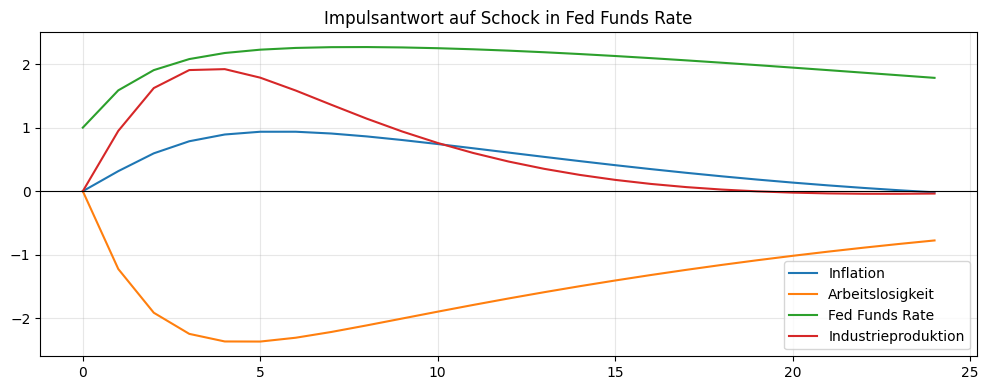

In [17]:
def impulse_response(model, shock, steps, size=1.0):
    # Wie reagiert das System ueber die Zeit auf einen einmaligen Schock?
    cols = list(model["columns"])
    k = len(cols)
    p = int(model["p"])
    coef = model["coef"]

    v = np.zeros(k)
    v[cols.index(shock)] = size          # Schock in Periode 0
    responses = [v]

    for h in range(1, steps + 1):
        y = np.zeros(k)
        for lag in range(1, p + 1):
            prev = responses[h - lag] if h - lag >= 0 else np.zeros(k)
            block = coef[1 + (lag - 1) * k : 1 + lag * k, :]
            y += prev @ block
        responses.append(y)

    return pd.DataFrame(responses, columns=cols)


irf = impulse_response(model, "fed_funds_rate", 24, size=1.0)
irf.rename(columns=NAMES).plot(figsize=(10, 4), title="Impulsantwort auf Schock in Fed Funds Rate")
plt.axhline(0, color="black", lw=0.8)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Fazit

- Ein VAR ist „nur“ eine clevere lineare Regression auf verzögerten Werten –
  aber mit reicher Systemdynamik.
- **Lag-Matrix, OLS, AIC/BIC, Forecast, Stabilität, IRF**: alles in wenigen
  Zeilen `numpy` nachbaubar.
- **Ehrliche Bewertung** (zeitlicher Split, kein Leakage, naive Benchmark) ist
  wichtiger als ein komplexes Modell.
- **Kausalität** folgt nicht automatisch aus Koeffizienten, Granger-Hinweisen
  oder Impulsantworten.

### Weiterdenken
- Mit **ersten Differenzen** statt Levels arbeiten (Stationarität) und RMSE
  vergleichen.
- Auf den **Beijing-Luftqualitätsdatensatz** (`beijing_air_quality_tiantan_daily_var.csv`)
  wechseln – dort sind Tagesdaten und andere Wechselwirkungen interessant.
- Mit `statsmodels` (`from statsmodels.tsa.api import VAR`) gegenchecken, ob die
  eigene Implementierung zu denselben Ergebnissen kommt.
